In [1]:
from utils import *

In [ ]:
EJ=8.9
EC=2.5
EL=0.5
g_strength = 0.3

E_osc = 3

qubit_level = 4
osc_level = 25

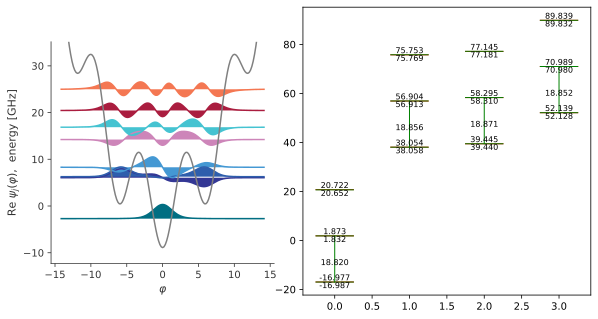

In [ ]:
qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=30,truncated_dim=qubit_level)
osc = scqubits.Oscillator(E_osc=E_osc,truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())
plot_specturum(qbt, osc, hilbertspace)

done:200/200


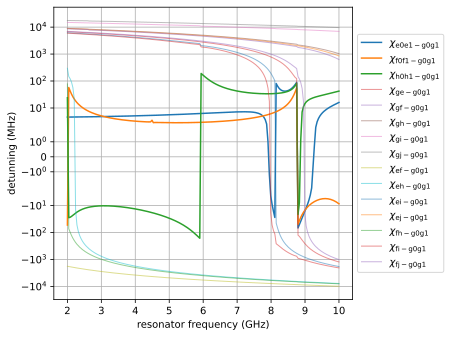

In [ ]:
# sweep_resonator_frequency_for_ge_gf_gh_detunning(EJ=8.9,
#                                         EC=2.5,
#                                         EL=0.5,
#                                         flux = 0,
#                                         g_strength = 0.3)

In [ ]:
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())
a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)
a = qutip.Qobj(a[:, :])
 
(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),
        dims=[hilbertspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])

leakage_dressed_state_osc_0 = product_to_dressed[(0,0)]
leakage_dressed_state_osc_1 = product_to_dressed[(0,1)]
w_d = transition_frequency(hilbertspace,leakage_dressed_state_osc_0,leakage_dressed_state_osc_1 )
# w_d = transition_frequency(hilbertspace,product_to_dressed[(0,0)], product_to_dressed[(0,1)])/2+transition_frequency(hilbertspace,product_to_dressed[(3,0)], product_to_dressed[(3,1)])/2


tot_time = 500

matrix_element_driven = abs((a+a.dag()).data.toarray()[leakage_dressed_state_osc_0][leakage_dressed_state_osc_1])


A_square = 1/tot_time
A_square = A_square/matrix_element_driven


def square_cos(t,*args):
    cos = np.cos(w_d * 2*np.pi * t)
    return  2*np.pi *A_square * cos

H_with_drive = [
    diag_dressed_hamiltonian,
    [a+a.dag(), square_cos]]

kappa = 0.01
decay_term = np.sqrt(kappa)*a

tot_time = int(tot_time * 1.5)
tlist = np.linspace(0, tot_time, tot_time*2)

results = []
for i in range(4):
    temp = solve_with_mcsolve(
        H = H_with_drive,
        state0=  qutip.basis(hilbertspace.dimension, product_to_dressed[(i,0)]),
        tlist = tlist,
        options=qutip.Options(store_states=True,nsteps=1000,num_cpus = 12),
        c_ops= [decay_term],
        ntraj= 100
    )
    results.append(temp)

10.0%. Run time:  61.42s. Est. time left: 00:00:09:12
20.0%. Run time:  62.02s. Est. time left: 00:00:04:08
30.0%. Run time: 127.62s. Est. time left: 00:00:04:57
40.0%. Run time: 129.18s. Est. time left: 00:00:03:13
50.0%. Run time: 199.08s. Est. time left: 00:00:03:19
60.0%. Run time: 201.17s. Est. time left: 00:00:02:14
70.0%. Run time: 202.04s. Est. time left: 00:00:01:26
80.0%. Run time: 271.82s. Est. time left: 00:00:01:07
90.0%. Run time: 273.55s. Est. time left: 00:00:00:30
100.0%. Run time: 307.31s. Est. time left: 00:00:00:00
Total run time: 307.35s
10.0%. Run time:  57.30s. Est. time left: 00:00:08:35
20.0%. Run time:  57.95s. Est. time left: 00:00:03:51
30.0%. Run time: 112.09s. Est. time left: 00:00:04:21
40.0%. Run time: 113.23s. Est. time left: 00:00:02:49
50.0%. Run time: 165.57s. Est. time left: 00:00:02:45
60.0%. Run time: 167.39s. Est. time left: 00:00:01:51
70.0%. Run time: 168.27s. Est. time left: 00:00:01:12
80.0%. Run time: 221.17s. Est. time left: 00:00:00:55
90.

In [ ]:
import pickle

with open('mcsolve750ns_with_decay.pkl', 'wb') as file:
    pickle.dump(results, file)

# with open('mcsolve750ns_with_decay.pkl', 'rb') as file:
#     results = pickle.load(file)

 /home/jiakai/.local/lib/python3.10/site-packages/jax/_src/array.py: 363

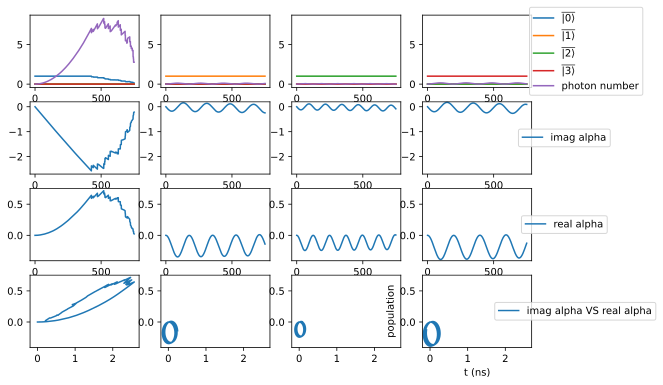

In [ ]:
plot_population(results,qubit_level,osc_level,product_to_dressed,a,w_d,tlist,fourier=True)

In [ ]:
import qutip as qt

final_qubit_states = []
for initial_state in [0,1,2,3]:
    final_state = results[initial_state].states[-1]
    if final_state.type != 'oper':
        final_state = qt.ket2dm(qutip.Qobj(final_state))
    rho_product = qt.Qobj(dims = [[qubit_level,osc_level],[qubit_level,osc_level]])
    for (ql, ol), dressed_level in product_to_dressed.items():
        qubit_state = qt.basis(qubit_level, ql)
        osc_state = qt.basis(osc_level, ol)
        product_state = qt.tensor(qubit_state, osc_state)
        rho_product += product_state * product_state.dag() * final_state.data[dressed_level, dressed_level]
    qubit_rho = rho_product.ptrace(0)
    final_qubit_states.append(qubit_rho)
